# 08 - Loss of Exclusivity

## Purpose

Explore how HealthSynth simulates the commercial impact of a pharmaceutical product losing market exclusivity.

This notebook demonstrates how:

- a product retains its competitive strength before loss of exclusivity
- competitive strength erodes gradually after the LOE date
- market share shifts toward competing products
- prescription allocation changes as the market evolves
- total market demand remains internally consistent

The objective is to understand Loss of Exclusivity as a commercial market event rather than simply observing declining prescription records.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from healthsynth.generator import generate

In [2]:
datasets = generate(
    config_path="../configs/profiles/oncology_loe.yaml",
    output_dir="../output/loe_analysis",
)

In [3]:
products = datasets["product"]
market_share = datasets["market_share"]
prescriptions = datasets["prescriptions"]
market_demand = datasets["market_demand"]
call_activity = datasets["call_activity"]
promotion_effect = datasets["promotion_effect"]

## The Commercial Scenario

Loss of Exclusivity, commonly abbreviated as **LOE**, occurs when a pharmaceutical product loses patent or regulatory protection.

After LOE, the original brand may face:

- generic or biosimilar competition
- lower pricing power
- reduced formulary preference
- switching by healthcare providers
- declining promotional investment
- rapid erosion of market share

HealthSynth models LOE as a decline in the product's competitive strength over time.

```text
Loss of Exclusivity
        ↓
Competitive Strength Erosion
        ↓
Lower Market Share
        ↓
Lower Product Demand
        ↓
Prescription Reallocation
```

The product does not disappear immediately. Instead, its competitive position declines gradually until it reaches a configured post-LOE floor.

In [4]:
product_columns = [
    "product_id",
    "product_name",
    "manufacturer",
    "brand_type",
    "launch_date",
    "baseline_market_share",
    "loe_date",
    "loe_erosion_months",
    "post_loe_share_factor",
]

products[product_columns]

,product_id,product_name,manufacturer,brand_type,launch_date,baseline_market_share,loe_date,loe_erosion_months,post_loe_share_factor
0,P001,OncoNova,NVA Pharma,Innovator,2022-01-01,0.45,2024-01-01,8.0,0.3
1,P002,Tumora,Competitor A,Competitor,2022-07-01,0.35,NaN,NaN,NaN
2,P003,Immunex,Competitor B,Competitor,2021-01-01,0.20,NaN,NaN,NaN


## Understanding the LOE Configuration

The LOE product contains three important settings:

- `loe_date` identifies when exclusivity is lost.
- `loe_erosion_months` determines how long competitive erosion takes.
- `post_loe_share_factor` defines the remaining competitive strength after erosion is complete.

For example:

```yaml
loe_date: "2024-01-01"
loe_erosion_months: 8
post_loe_share_factor: 0.30
```

This means that the product retains full competitive strength before January 2024. It then declines over eight months until its competitive factor reaches 30% of its pre-LOE level.

The factor affects competitive strength rather than directly setting final market share.

In [5]:
market_share["month"] = pd.to_datetime(
    market_share["month"]
)

prescriptions["rx_date"] = pd.to_datetime(
    prescriptions["rx_date"]
)

market_demand["month"] = pd.to_datetime(
    market_demand["month"]
)

products["loe_date"] = pd.to_datetime(
    products["loe_date"],
    errors="coerce",
)

loe_product = products[
    products["loe_date"].notna()
].iloc[0]

loe_product_id = loe_product["product_id"]
loe_product_name = loe_product["product_name"]
loe_date = loe_product["loe_date"]

loe_product[
    [
        "product_id",
        "product_name",
        "loe_date",
        "loe_erosion_months",
        "post_loe_share_factor",
    ]
]

product_id                              P001
product_name                        OncoNova
loe_date                 2024-01-01 00:00:00
loe_erosion_months                       8.0
post_loe_share_factor                    0.3
Name: 0, dtype: object

## Competitive Strength Before and After LOE

HealthSynth represents LOE through an `loe_factor`.

Before LOE:

```text
LOE factor = 1.0
```

During erosion:

```text
1.0
 ↓
0.9
 ↓
0.8
 ↓
...
```

After erosion:

```text
LOE factor = configured floor
```

The LOE factor is multiplied by the product's competitive score before market shares are normalized across all products.

In [6]:
loe_market_share = market_share[
    market_share["product_id"] == loe_product_id
].copy()

loe_market_share[
    [
        "month",
        "loe_factor",
        "adjusted_market_share",
    ]
].head(18)

,month,loe_factor,adjusted_market_share
0,2023-01-01,1.0000,0.419635
3,2023-02-01,1.0000,0.436143
6,2023-03-01,1.0000,0.415505
9,2023-04-01,1.0000,0.426871
12,2023-05-01,1.0000,0.423808
15,2023-06-01,1.0000,0.428404
18,2023-07-01,1.0000,0.423895
21,2023-08-01,1.0000,0.436827
24,2023-09-01,1.0000,0.425838
27,2023-10-01,1.0000,0.416964


In [7]:
pre_loe = loe_market_share[
    loe_market_share["month"] < loe_date
]

assert (
    pre_loe["loe_factor"] == 1.0
).all()

print("LOE factor remains 1.0 before loss of exclusivity.")

LOE factor remains 1.0 before loss of exclusivity.


## Visualizing the LOE Erosion Curve

The LOE factor represents the product's remaining competitive strength.

It should decline gradually rather than creating an immediate collapse in the LOE month.

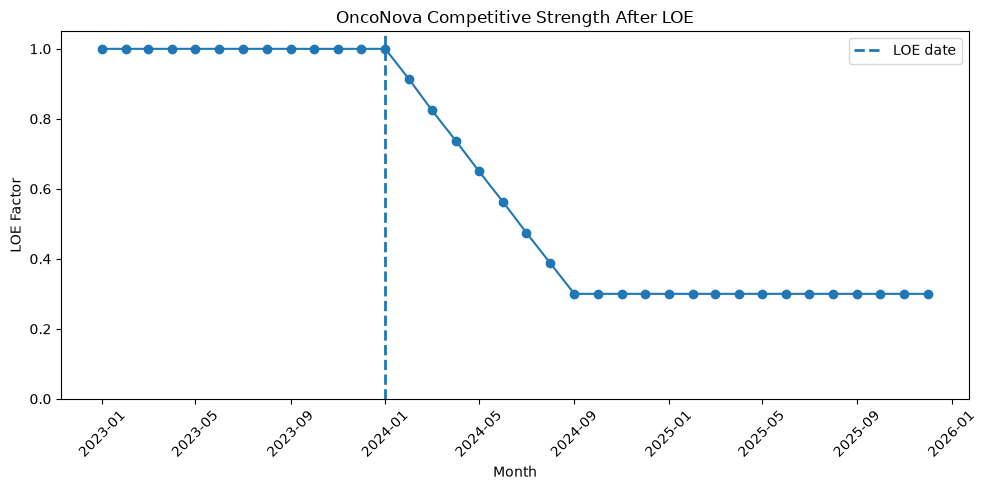

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(
    loe_market_share["month"],
    loe_market_share["loe_factor"],
    marker="o",
)

plt.axvline(
    loe_date,
    linestyle="--",
    linewidth=2,
    label="LOE date",
)

plt.title(f"{loe_product_name} Competitive Strength After LOE")
plt.xlabel("Month")
plt.ylabel("LOE Factor")
plt.ylim(0, 1.05)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpreting the LOE Factor

The product remains fully competitive before LOE.

After the LOE date, its competitive factor declines over the configured erosion period until it reaches the post-LOE floor.

The LOE factor is not the same as market share.

For example, an LOE factor of `0.30` means the product retains 30% of its former competitive strength. Its final market share still depends on:

- competitor strength
- promotional activity
- baseline share
- random market variation
- normalization across all active products

## Market Share Evolution

As the LOE product loses competitive strength, other products receive a larger portion of the market.

This redistribution happens through the normal market-share calculation:

```text
Product Competitive Scores
        ↓
Apply LOE Factor
        ↓
Normalize Across Products
        ↓
Adjusted Market Share
```

In [9]:
market_share_named = market_share.merge(
    products[
        [
            "product_id",
            "product_name",
        ]
    ],
    on="product_id",
    how="left",
)

market_share_plot = market_share_named.pivot(
    index="month",
    columns="product_name",
    values="adjusted_market_share",
)

market_share_plot.head()

product_name,Immunex,OncoNova,Tumora
month,,,
2023-01-01,0.221927,0.419635,0.358438
2023-02-01,0.225133,0.436143,0.338724
2023-03-01,0.224102,0.415505,0.360392
2023-04-01,0.228313,0.426871,0.344816
2023-05-01,0.230566,0.423808,0.345626


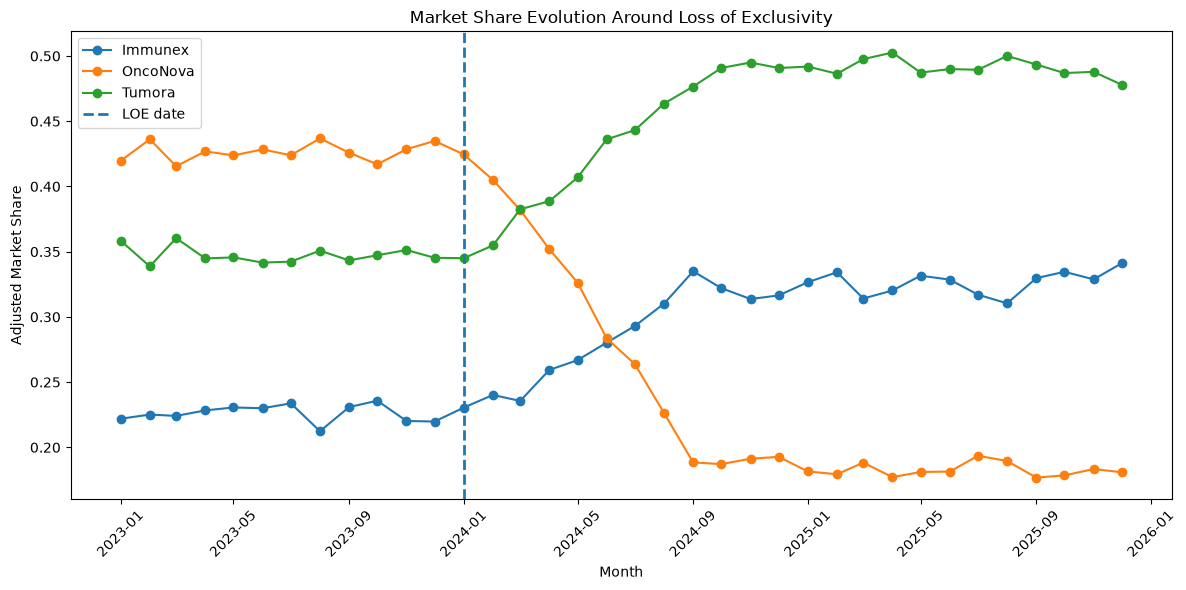

In [10]:
plt.figure(figsize=(12, 6))

for product_name in market_share_plot.columns:
    plt.plot(
        market_share_plot.index,
        market_share_plot[product_name],
        marker="o",
        label=product_name,
    )

plt.axvline(
    loe_date,
    linestyle="--",
    linewidth=2,
    label="LOE date",
)

plt.title("Market Share Evolution Around Loss of Exclusivity")
plt.xlabel("Month")
plt.ylabel("Adjusted Market Share")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observations

The LOE product's market share does not collapse immediately.

Instead:

- share remains relatively stable before LOE
- erosion begins after exclusivity is lost
- competitors absorb increasing portions of the market
- share stabilizes once the configured LOE floor is reached

Month-to-month movement may not be perfectly smooth because promotion and market noise continue to affect every product.

In [11]:
comparison_months = [
    loe_date - pd.DateOffset(months=1),
    loe_date + pd.DateOffset(months=4),
    loe_date + pd.DateOffset(months=8),
]

share_comparison = (
    market_share_named[
        market_share_named["month"].isin(
            comparison_months
        )
    ]
    .pivot(
        index="product_name",
        columns="month",
        values="adjusted_market_share",
    )
)

share_comparison

month,2023-12-01,2024-05-01,2024-09-01
product_name,,,
Immunex,0.219792,0.266834,0.334943
OncoNova,0.434905,0.326302,0.188474
Tumora,0.345303,0.406864,0.476583


## Prescription Impact

HealthSynth does not directly reduce prescription records because a product reaches LOE.

Instead, prescription changes emerge from the commercial simulation:

```text
LOE Factor Declines
        ↓
Adjusted Market Share Declines
        ↓
Product Receives Less Market Demand
        ↓
Lower Generated NRx
```

Competitors receive a larger share of the same total market demand.

In [12]:
rx_named = prescriptions.merge(
    products[
        [
            "product_id",
            "product_name",
        ]
    ],
    on="product_id",
    how="left",
)

monthly_rx = (
    rx_named.groupby(
        [
            "rx_date",
            "product_name",
        ]
    )["nrx"]
    .sum()
    .reset_index()
)

monthly_rx.head()

,rx_date,product_name,nrx
0,2023-01-01,Immunex,150
1,2023-01-01,OncoNova,282
2,2023-01-01,Tumora,231
3,2023-02-01,Immunex,153
4,2023-02-01,OncoNova,311


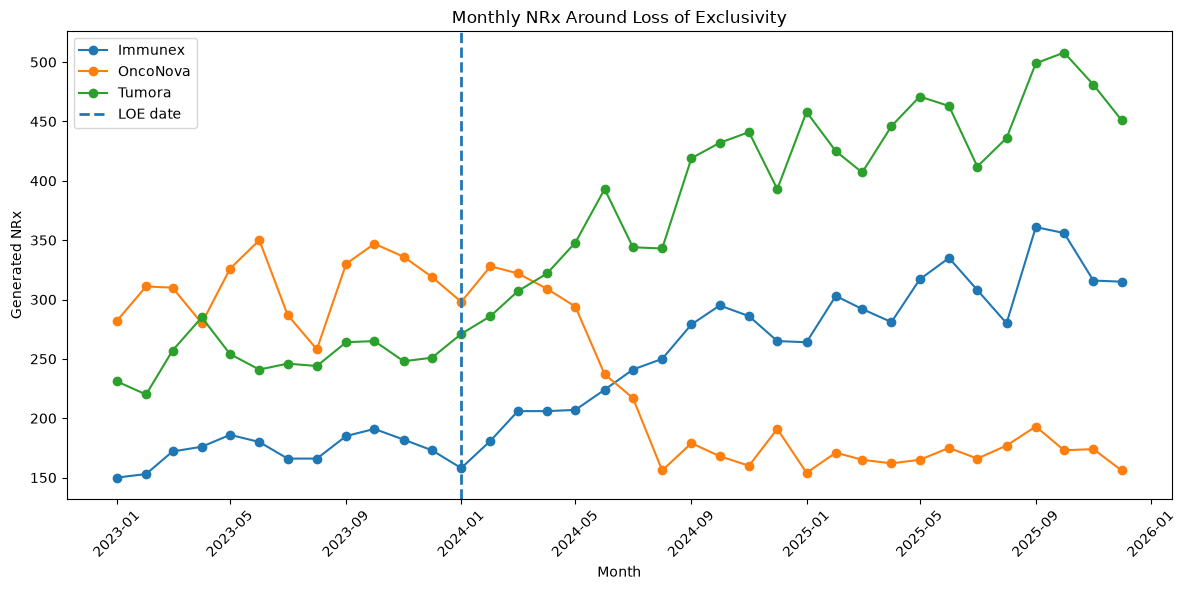

In [13]:
rx_plot = monthly_rx.pivot(
    index="rx_date",
    columns="product_name",
    values="nrx",
)

plt.figure(figsize=(12, 6))

for product_name in rx_plot.columns:
    plt.plot(
        rx_plot.index,
        rx_plot[product_name],
        marker="o",
        label=product_name,
    )

plt.axvline(
    loe_date,
    linestyle="--",
    linewidth=2,
    label="LOE date",
)

plt.title("Monthly NRx Around Loss of Exclusivity")
plt.xlabel("Month")
plt.ylabel("Generated NRx")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
loe_product_rx = monthly_rx[
    monthly_rx["product_name"] == loe_product_name
].copy()

loe_product_rx[
    (
        loe_product_rx["rx_date"]
        >= loe_date - pd.DateOffset(months=3)
    )
    & (
        loe_product_rx["rx_date"]
        <= loe_date + pd.DateOffset(months=10)
    )
]

,rx_date,product_name,nrx
28,2023-10-01,OncoNova,347
31,2023-11-01,OncoNova,336
34,2023-12-01,OncoNova,319
37,2024-01-01,OncoNova,298
40,2024-02-01,OncoNova,328
43,2024-03-01,OncoNova,322
46,2024-04-01,OncoNova,309
49,2024-05-01,OncoNova,294
52,2024-06-01,OncoNova,237
55,2024-07-01,OncoNova,217


### Prescription Volume and Market Share

Absolute prescription volume may not decline every single month after LOE.

This is because NRx depends on both:

- the product's market share
- total market demand

A product may temporarily experience higher prescriptions despite declining share if the overall market expands or experiences seasonal growth.

Commercial analysts should therefore evaluate LOE using both relative and absolute measures.

## Market Demand Reconciliation

Loss of Exclusivity changes how prescriptions are distributed across products.

It should not create or remove unexplained market demand.

For every month:

```text
Total Generated NRx
        =
Simulated Market NRx
```

In [15]:
monthly_generated_nrx = (
    prescriptions.groupby("rx_date")["nrx"]
    .sum()
    .reset_index(name="generated_nrx")
    .rename(columns={"rx_date": "month"})
)

monthly_generated_nrx["month"] = pd.to_datetime(
    monthly_generated_nrx["month"]
)

demand_reconciliation = market_demand[
    [
        "month",
        "market_nrx",
    ]
].merge(
    monthly_generated_nrx,
    on="month",
    how="left",
)

demand_reconciliation["difference"] = (
    demand_reconciliation["generated_nrx"]
    - demand_reconciliation["market_nrx"]
)

demand_reconciliation.head()

,month,market_nrx,generated_nrx,difference
0,2023-01-01,663,663,0
1,2023-02-01,684,684,0
2,2023-03-01,739,739,0
3,2023-04-01,741,741,0
4,2023-05-01,766,766,0


In [16]:
assert (
    demand_reconciliation["difference"] == 0
).all()

print(
    "Monthly generated NRx reconciles exactly "
    "with simulated market demand."
)

Monthly generated NRx reconciles exactly with simulated market demand.


> **Business Insight**
>
> Loss of Exclusivity is not simply a decline in prescription volume.
>
> It is a shift in competitive position.
>
> Analysts should examine:
>
> - the speed of share erosion
> - the post-LOE market-share floor
> - which competitors benefit
> - whether market growth masks product decline
> - how rapidly prescription allocation changes
>
> A product may retain meaningful prescription volume after LOE while still experiencing severe competitive erosion.

## Key Takeaways

- LOE begins on a configured product-specific date.
- Competitive erosion develops gradually rather than occurring as an immediate collapse.
- The LOE factor measures remaining competitive strength, not final market share.
- Declining competitive strength reduces adjusted market share.
- Competing products absorb more of the available market.
- Prescription changes emerge from market-share redistribution.
- Absolute NRx may fluctuate because total market demand continues to change.
- Monthly generated NRx remains fully reconciled with upstream market demand.

HealthSynth models LOE as a connected commercial event:

```text
Loss of Exclusivity
        ↓
Competitive Erosion
        ↓
Market Share Redistribution
        ↓
Prescription Impact
        ↓
Commercial Analysis
```